<a href="https://colab.research.google.com/github/syltaer-utp/Project-S100/blob/main/S100_Equipo2_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S100 — Parte II. Proyecto Final
## Gasto en salud y esperanza de vida (América + Europa, 2000–2024)

**Equipo 2** · Universidad Tecnológica de Panamá  
Curso: Introducción a la Ciencia de Datos (S100)

Este cuaderno completa el ciclo de ciencia de datos: limpieza documentada, análisis exploratorio, diseño de evaluación, baseline, dos algoritmos supervisados (árbol de regresión y kNN) con ajuste de hiperparámetros y validación cruzada, tabla comparativa train/test y espacio para interpretación.

**Hipótesis (Parte I):**  
A mayor gasto en salud per cápita (USD), mayor esperanza de vida total, controlando por PIB per cápita, año y continente.

## 1. Librerías y configuración

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga del dataset

Se carga `health_panel.csv` (panel país-año construido a partir de World Bank, WHO y OECD).  
Contiene indicadores de esperanza de vida, gasto en salud, mortalidad, PIB y recursos sanitarios.

In [28]:
DATA_PATH = "health_panel.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape original: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Años: {df['year'].min()} – {df['year'].max()}")
print(f"Países/entidades: {df['country_name'].nunique()}")
print(f"\nColumnas:\n{list(df.columns)}")

Shape original: 17,210 filas × 32 columnas
Años: 1960 – 2024
Países/entidades: 265

Columnas:
['country_code', 'country_name', 'year', 'life_expectancy_total', 'life_expectancy_female', 'life_expectancy_male', 'life_expectancy_gender_gap', 'le_total_yoy_change', 'region', 'income_group', 'iso2_code', 'health_spend_pct_gdp', 'health_spend_per_capita_usd', 'spend_pct_gdp_yoy_change', 'spend_per_capita_yoy_pct', 'hospital_beds_per_1000', 'physicians_per_1000', 'nurses_midwives_per_1000', 'total_health_workers_per_1000', 'infant_mortality_per_1000', 'under5_mortality_per_1000', 'maternal_mortality_per_100k', 'infant_mortality_yoy_change', 'under5_mortality_yoy_change', 'gdp_per_capita_usd', 'population_total', 'log_gdp_per_capita', 'gdp_per_capita_yoy_pct', 'le_per_gdp_point', 'le_per_1k_spend', 'le_spend_residual', 'efficiency_score']


## 3. Limpieza y construcción del subset de trabajo

**Decisiones de limpieza (justificadas):**

1. **Solo países individuales de América y Europa** — se excluyen agregados regionales ("Latin America & Caribbean", "Europe & Central Asia", etc.) para que la unidad de observación sea país-año.
2. **Años ≥ 2000** — mayor cobertura y comparabilidad de gasto en salud; reduce huecos históricos.
3. **Filas con `life_expectancy_total` y `health_spend_per_capita_usd` no nulos** — sin estas dos variables no se puede evaluar la hipótesis.
4. **Eliminación de columnas vacías, códigos ISO y variables derivadas** — no aportan información nueva o están 100 % vacías en el subset.
5. **Creación de `continent`** — variable categórica de control (Américas vs Europa).
6. **Tratamiento de faltantes en predictoras numéricas** — se eliminan filas con PIB nulo antes del split porque el porcentaje es bajo y facilita la comparación de modelos (evita imputación que podría sesgar la comparación entre algoritmos).

In [29]:
americas = [
    "Antigua and Barbuda", "Argentina", "Bahamas, The", "Barbados", "Belize",
    "Bolivia", "Brazil", "Canada", "Chile", "Colombia", "Costa Rica", "Cuba",
    "Dominica", "Dominican Republic", "Ecuador", "El Salvador", "Grenada",
    "Guatemala", "Guyana", "Haiti", "Honduras", "Jamaica", "Mexico",
    "Nicaragua", "Panama", "Paraguay", "Peru", "St. Kitts and Nevis",
    "St. Lucia", "St. Vincent and the Grenadines", "Suriname",
    "Trinidad and Tobago", "United States", "Uruguay", "Venezuela, RB",
]

europe = [
    "Albania", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina",
    "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia",
    "Finland", "France", "Germany", "Greece", "Hungary", "Iceland",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Moldova", "Montenegro", "Netherlands", "North Macedonia", "Norway",
    "Poland", "Portugal", "Romania", "Russian Federation", "Serbia",
    "Slovak Republic", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Ukraine", "United Kingdom",
]

# Filtrar países y crear continente
df_ae = df[df["country_name"].isin(americas + europe)].copy()
df_ae["continent"] = np.where(df_ae["country_name"].isin(americas), "Americas", "Europe")

# Años >= 2000
df_ae = df_ae[df_ae["year"] >= 2000].copy()

# Quitar columnas vacías, redundantes y derivadas
cols_eliminar = [
    "region", "income_group", "iso2_code", "country_code",
    "le_per_gdp_point", "le_per_1k_spend", "le_spend_residual", "efficiency_score",
]
df_ae = df_ae.drop(columns=cols_eliminar, errors="ignore")

# Subset final: LE, gasto y PIB no nulos
df_subset = df_ae.dropna(
    subset=["life_expectancy_total", "health_spend_per_capita_usd", "gdp_per_capita_usd"]
).copy()

print(f"df_subset: {df_subset.shape[0]:,} filas × {df_subset.shape[1]} columnas")
print(f"Años: {df_subset['year'].min()} – {df_subset['year'].max()}")
print(f"Países: {df_subset['country_name'].nunique()}")
print("\nPor continente:")
print(df_subset["continent"].value_counts())
print("\nFaltantes residuales:")
print(df_subset[["life_expectancy_total", "health_spend_per_capita_usd",
                 "gdp_per_capita_usd", "year", "continent"]].isnull().sum())

df_subset: 1,786 filas × 25 columnas
Años: 2000 – 2024
Países: 75

Por continente:
continent
Europe      964
Americas    822
Name: count, dtype: int64

Faltantes residuales:
life_expectancy_total          0
health_spend_per_capita_usd    0
gdp_per_capita_usd             0
year                           0
continent                      0
dtype: int64


## 4. Análisis exploratorio

El análisis exploratorio informa las decisiones de modelado: distribución de la variable objetivo, sesgo de las predictoras y relación visual con la hipótesis.

### 4.1 Tabla de estadísticos descriptivos

In [30]:
desc_vars = [
    "life_expectancy_total",
    "health_spend_per_capita_usd",
    "gdp_per_capita_usd",
    "infant_mortality_per_1000",
]
df_desc = df_ae.dropna(subset=["life_expectancy_total"]).copy()

desc = df_subset[desc_vars].describe().T[["mean", "50%", "min", "max", "std"]]
desc = desc.rename(columns={"50%": "median"})
desc = desc.round(2)
print("Tabla 1. Estadísticos descriptivos (subset América + Europa, ≥ 2000)")
print(desc.to_string())

Tabla 1. Estadísticos descriptivos (subset América + Europa, ≥ 2000)
                                 mean    median     min        max       std
life_expectancy_total           75.52     75.66   45.58      84.16      4.79
health_spend_per_capita_usd   1770.71    779.39   18.61   13473.19   2195.96
gdp_per_capita_usd           20610.27  11694.69  440.54  137781.68  22351.27
infant_mortality_per_1000       10.99      7.50    1.50      79.30      9.82


**Espacio para interpretación de la Tabla 1:**  
> La esperanza de vida es relativamente simétrica (media ≈ mediana ≈ 75,5 años; DE ≈ 4,8), con un rango amplio (45,6–84,2) que refleja heterogeneidad entre países. El gasto en salud y el PIB muestran sesgo positivo fuerte (media muy por encima de la mediana): hay una cola derecha de países de alto ingreso/gasto. Eso justifica no asumir linealidad y favorece modelos como el árbol o kNN, que no imponen una forma funcional global. La mortalidad infantil también está sesgada a la derecha y se usa solo en el EDA, no en el modelado.

### 4.2 Figura 1 — Distribución de la variable objetivo

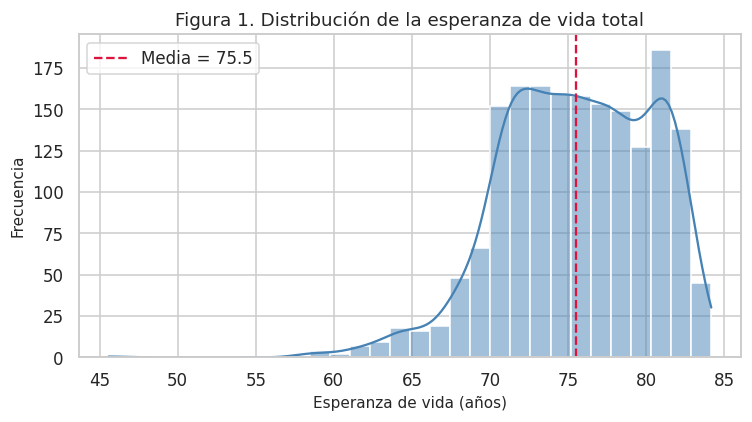

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_subset, x="life_expectancy_total", bins=30, kde=True,
             color="steelblue", ax=ax)
ax.axvline(df_subset["life_expectancy_total"].mean(), color="crimson",
           linestyle="--", label=f"Media = {df_subset['life_expectancy_total'].mean():.1f}")
ax.set_title("Figura 1. Distribución de la esperanza de vida total")
ax.set_xlabel("Esperanza de vida (años)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

**Espacio para interpretación de la Figura 1:**  
> La masa se concentra entre ~ 70 y 82 años, con una cola izquierda (países/años de menor LE). La distribución no es normal perfecta, pero tampoco tiene outliers extremos que invaliden RMSE/MAE. El RMSE del baseline (~4,5–4,9 años) es del orden de una desviación estándar, lo que marca el piso a superar.

### 4.3 Figura 2 — Relación gasto en salud ↔ esperanza de vida (hipótesis)

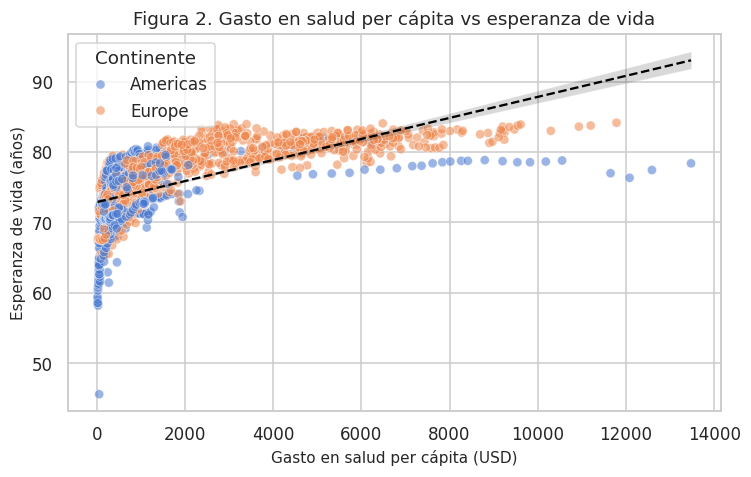

Correlación de Pearson (gasto ↔ LE): 0.685


In [32]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(
    data=df_subset, x="health_spend_per_capita_usd", y="life_expectancy_total",
    hue="continent", alpha=0.55, ax=ax
)
sns.regplot(
    data=df_subset, x="health_spend_per_capita_usd", y="life_expectancy_total",
    scatter=False, color="black", ax=ax, line_kws={"linewidth": 1.5, "linestyle": "--"}
)
ax.set_title("Figura 2. Gasto en salud per cápita vs esperanza de vida")
ax.set_xlabel("Gasto en salud per cápita (USD)")
ax.set_ylabel("Esperanza de vida (años)")
ax.legend(title="Continente")
plt.tight_layout()
plt.show()

corr = df_subset[["health_spend_per_capita_usd", "life_expectancy_total"]].corr().iloc[0, 1]
print(f"Correlación de Pearson (gasto ↔ LE): {corr:.3f}")

**Espacio para interpretación de la Figura 2:**  
> Hay una relación positiva clara (correlación de Pearson = 0,685): a mayor gasto per cápita, mayor LE. Europa tiende a situarse en la zona de mayor gasto y mayor LE; América muestra más dispersión en el tramo bajo-medio de gasto. La nube no es una recta perfecta (aplanamiento a altos niveles de gasto), lo que anticipa ganancias de un modelo no lineal. El patrón va en la dirección de la hipótesis, sin implicar causalidad.

## 5. Definición de X e y

- **y:** `life_expectancy_total` (continua → problema de **regresión**)
- **X:** gasto en salud (variable central de la hipótesis), PIB per cápita, año y continente (controles)

In [33]:
features = [
    "health_spend_per_capita_usd",
    "gdp_per_capita_usd",
    "year",
    "continent",
]

X = df_subset[features].copy()
y = df_subset["life_expectancy_total"].copy()

print(f"X: {X.shape} | y: {y.shape}")
print(f"Faltantes X:\n{X.isnull().sum()}")
print(f"Faltantes y: {y.isnull().sum()}")

X: (1786, 4) | y: (1786,)
Faltantes X:
health_spend_per_capita_usd    0
gdp_per_capita_usd             0
year                           0
continent                      0
dtype: int64
Faltantes y: 0


## 6. Diseño de evaluación: train / test + semilla fija

- 80 % entrenamiento, 20 % prueba.
- `random_state=42` para reproducibilidad.
- Unidad de observación: país-año (no se agrupa por país ni por año).

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1428 filas
Test:  358 filas


## 7. Función auxiliar de métricas

Se calculan **RMSE, MAE y R²** tanto en entrenamiento como en prueba para diagnosticar sobreajuste.

In [35]:
def metricas(y_true, y_pred, etiqueta=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if etiqueta:
        print(f"{etiqueta}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  MAE:  {mae:.3f}")
        print(f"  R²:   {r2:.3f}")
    return {"RMSE": rmse, "MAE": mae, "R²": r2}

## 8. Baseline: predecir siempre la media

El baseline predice el promedio de la esperanza de vida del conjunto de entrenamiento.  
Sirve como **piso de comparación**: cualquier modelo útil debe mejorar RMSE/MAE y obtener R² > 0.

In [36]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_b_train = baseline.predict(X_train)
y_pred_b_test  = baseline.predict(X_test)

m_b_train = metricas(y_train, y_pred_b_train, "Baseline — Train")
m_b_test  = metricas(y_test,  y_pred_b_test,  "Baseline — Test")

Baseline — Train
  RMSE: 4.872
  MAE:  3.993
  R²:   0.000
Baseline — Test
  RMSE: 4.464
  MAE:  3.716
  R²:   -0.011


## 9. Modelo 1: Árbol de regresión

**Por qué un árbol:**
1. Variable objetivo continua → regresión.
2. Captura relaciones no lineales (el efecto del gasto no tiene por qué ser lineal).
3. Permite importancia de variables para revisar la hipótesis.

**Preprocesamiento:** One-Hot Encoding de `continent` (sin orden artificial).

**Hiperparámetro:** `max_depth` y `min_samples_leaf` se ajustan con `GridSearchCV` (validación cruzada 5-fold sobre el train).

In [37]:
prep_tree = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["continent"]),
    ("num", "passthrough", [
        "health_spend_per_capita_usd",
        "gdp_per_capita_usd",
        "year",
    ]),
])

pipe_tree = Pipeline([
    ("prep", prep_tree),
    ("tree", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

# Ajuste de hiperparámetros con CV
param_grid_tree = {
    "tree__max_depth": [3, 4, 5, 6, 8, 10, None],
    "tree__min_samples_leaf": [5, 10, 20],
}

gs_tree = GridSearchCV(
    pipe_tree,
    param_grid_tree,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)
gs_tree.fit(X_train, y_train)

print("Mejores hiperparámetros (árbol):", gs_tree.best_params_)
print(f"Mejor RMSE CV (negativo → positivo): {-gs_tree.best_score_:.3f}")

best_tree = gs_tree.best_estimator_

y_pred_tree_train = best_tree.predict(X_train)
y_pred_tree_test  = best_tree.predict(X_test)

m_tree_train = metricas(y_train, y_pred_tree_train, "Árbol — Train")
m_tree_test  = metricas(y_test,  y_pred_tree_test,  "Árbol — Test")

Mejores hiperparámetros (árbol): {'tree__max_depth': 6, 'tree__min_samples_leaf': 5}
Mejor RMSE CV (negativo → positivo): 2.301
Árbol — Train
  RMSE: 2.043
  MAE:  1.503
  R²:   0.824
Árbol — Test
  RMSE: 2.334
  MAE:  1.737
  R²:   0.723


### 9.1 Gráficos del árbol de regresión

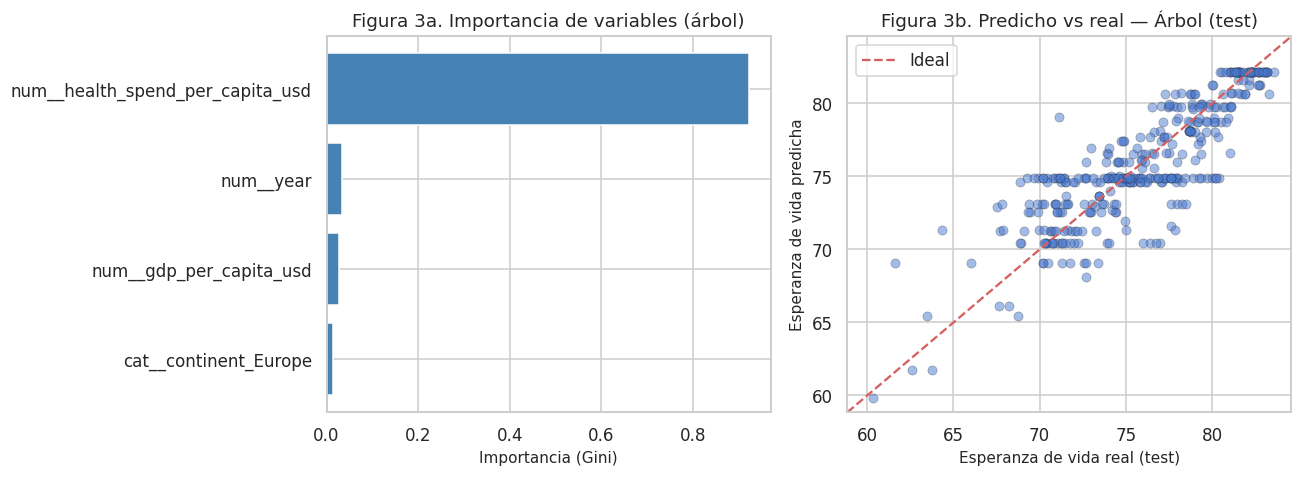


Importancias:
                         feature  importance
num__health_spend_per_capita_usd    0.923453
                       num__year    0.033680
         num__gdp_per_capita_usd    0.028213
           cat__continent_Europe    0.014654


In [38]:
# --- Importancia de variables ---
feature_names = best_tree.named_steps["prep"].get_feature_names_out()
importances = best_tree.named_steps["tree"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Importancia
axes[0].barh(imp_df["feature"], imp_df["importance"], color="steelblue")
axes[0].set_title("Figura 3a. Importancia de variables (árbol)")
axes[0].set_xlabel("Importancia (Gini)")

# Predicho vs real (test)
axes[1].scatter(y_test, y_pred_tree_test, alpha=0.5, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_pred_tree_test.min()) - 1,
        max(y_test.max(), y_pred_tree_test.max()) + 1]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Ideal")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("Esperanza de vida real (test)")
axes[1].set_ylabel("Esperanza de vida predicha")
axes[1].set_title("Figura 3b. Predicho vs real — Árbol (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nImportancias:")
print(imp_df.sort_values("importance", ascending=False).to_string(index=False))

**Espacio para interpretación del árbol (Figuras 3a–3b):**  
> Importancia de variables: el gasto en salud concentra el 92,3 % de la importancia; año (~ 3,4 %), PIB (~ 2,8 %) y continente (~1,5 %) aportan poco. La variable de la hipótesis es, con mucho, la más relevante del árbol.
Sobreajuste: ΔRMSE = 0,29 (train 2,04 → test 2,33); R² baja de 0,82 a 0,72. Hay algo de sobreajuste, acotado por max_depth=6 y min_samples_leaf=5.
Predicho vs real: los puntos se agrupan cerca de la diagonal; los errores mayores aparecen en los extremos (LE muy baja o muy alta).

### 9.2 Visualización de la estructura del árbol

Se grafica el árbol con la profundidad óptima encontrada por CV (`max_depth=6`).  
Para legibilidad se muestran como máximo 4 niveles; el modelo completo usa profundidad 6.

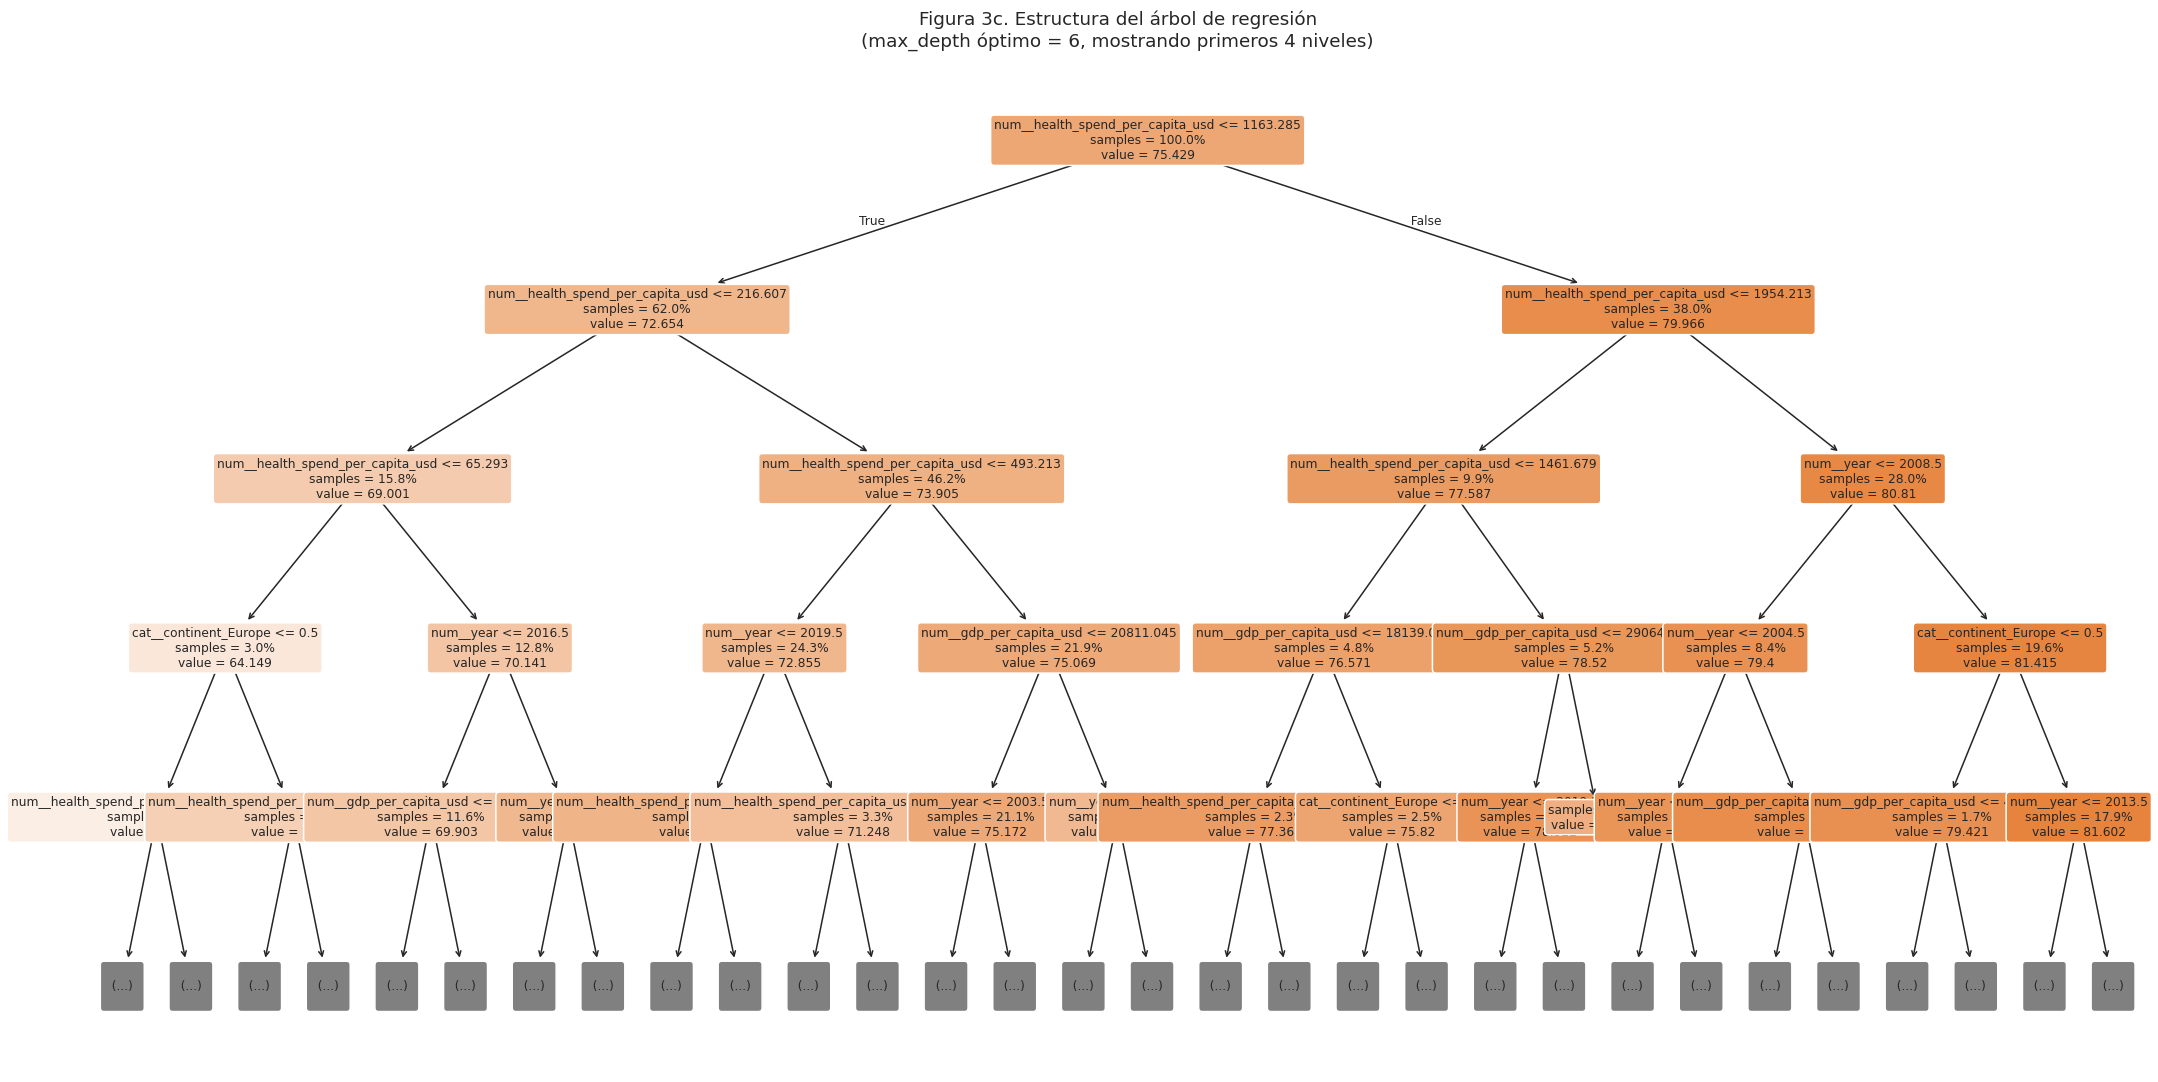

Profundidad real del árbol ajustado: 6
Número de hojas: 50
Número de nodos: 99


In [42]:
# Estructura del árbol de regresión (mejores hiperparámetros de GridSearchCV)
tree_model = best_tree.named_steps["tree"]
feat_names = best_tree.named_steps["prep"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feat_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,          # limitar a 4 niveles para que se lea; el modelo usa max_depth=6
    impurity=False,       # ocultar MSE en nodos para reducir ruido visual
    proportion=True,
    ax=ax,
)
ax.set_title(
    "Figura 3c. Estructura del árbol de regresión\n"
    f"(max_depth óptimo = {tree_model.get_depth()}, mostrando primeros 4 niveles)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print(f"Profundidad real del árbol ajustado: {tree_model.get_depth()}")
print(f"Número de hojas: {tree_model.get_n_leaves()}")
print(f"Número de nodos: {tree_model.tree_.node_count}")

### Interpretación de la estructura del árbol (Figura 3c)

El árbol parte casi siempre por el **gasto en salud per cápita**. La primera división es:

- **Gasto ≤ 1 163 USD** → LE promedio ≈ 72,9 años (rama izquierda).
- **Gasto > 1 163 USD** → LE promedio ≈ 80,0 años (rama derecha).

En la rama de gasto bajo/medio siguen dominando umbrales de gasto (≈ 65, 217, 493 USD). En la de gasto alto intervienen más el **año** y el **PIB**.

Las hojas predicen el promedio de esperanza de vida de las observaciones que caen en cada nodo. En conjunto, el árbol confirma que el gasto es el criterio principal y que año, PIB y continente solo afinan la predicción.

## 10. Modelo 2: k-Nearest Neighbors (kNN)

**Por qué kNN:**
1. Método no paramétrico que captura estructuras locales.
2. Complementa al árbol: no asume particiones globales.
3. Requiere escalado de variables numéricas (distancias sensibles a la escala).

**Preprocesamiento:** StandardScaler en numéricas + One-Hot Encoding de continente.

**Hiperparámetro:** `n_neighbors` (k) y `weights` se ajustan con `GridSearchCV` (5-fold).

In [39]:
prep_knn = ColumnTransformer([
    ("num", StandardScaler(), [
        "health_spend_per_capita_usd",
        "gdp_per_capita_usd",
        "year",
    ]),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["continent"]),
])

pipe_knn = Pipeline([
    ("prep", prep_knn),
    ("knn", KNeighborsRegressor()),
])

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
}

gs_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)
gs_knn.fit(X_train, y_train)

print("Mejores hiperparámetros (kNN):", gs_knn.best_params_)
print(f"Mejor RMSE CV: {-gs_knn.best_score_:.3f}")

best_knn = gs_knn.best_estimator_

y_pred_knn_train = best_knn.predict(X_train)
y_pred_knn_test  = best_knn.predict(X_test)

m_knn_train = metricas(y_train, y_pred_knn_train, "kNN — Train")
m_knn_test  = metricas(y_test,  y_pred_knn_test,  "kNN — Test")

Mejores hiperparámetros (kNN): {'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Mejor RMSE CV: 2.409
kNN — Train
  RMSE: 2.215
  MAE:  1.587
  R²:   0.793
kNN — Test
  RMSE: 2.281
  MAE:  1.711
  R²:   0.736


### 10.1 Gráficos del kNN

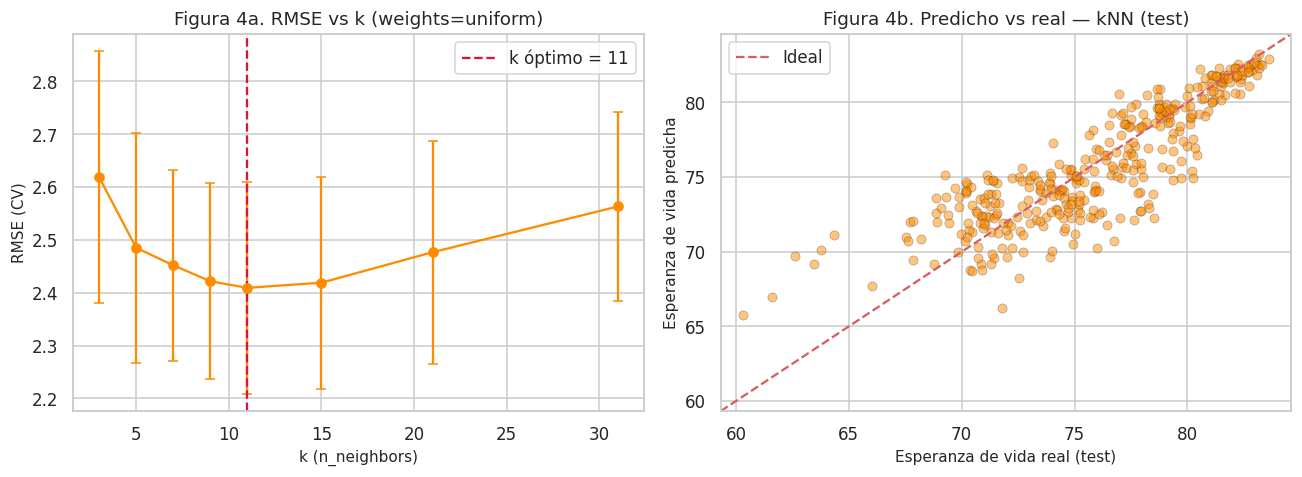

In [40]:
# Curva de validación: RMSE vs k
cv_results = pd.DataFrame(gs_knn.cv_results_)

best_weight = gs_knn.best_params_["knn__weights"]
mask = cv_results["param_knn__weights"] == best_weight
curve = cv_results.loc[mask, ["param_knn__n_neighbors", "mean_test_score", "std_test_score"]].copy()
curve["RMSE"] = -curve["mean_test_score"]
curve = curve.sort_values("param_knn__n_neighbors")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Curva RMSE vs k
axes[0].errorbar(curve["param_knn__n_neighbors"], curve["RMSE"],
                 yerr=curve["std_test_score"], marker="o", color="darkorange",
                 capsize=3)
axes[0].axvline(gs_knn.best_params_["knn__n_neighbors"], color="crimson",
                linestyle="--", label=f"k óptimo = {gs_knn.best_params_['knn__n_neighbors']}")
axes[0].set_xlabel("k (n_neighbors)")
axes[0].set_ylabel("RMSE (CV)")
axes[0].set_title(f"Figura 4a. RMSE vs k (weights={best_weight})")
axes[0].legend()

# Predicho vs real (test)
axes[1].scatter(y_test, y_pred_knn_test, alpha=0.5, edgecolor="k", linewidth=0.3,
                color="darkorange")
lims = [min(y_test.min(), y_pred_knn_test.min()) - 1,
        max(y_test.max(), y_pred_knn_test.max()) + 1]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Ideal")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("Esperanza de vida real (test)")
axes[1].set_ylabel("Esperanza de vida predicha")
axes[1].set_title("Figura 4b. Predicho vs real — kNN (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Espacio para interpretación del kNN (Figuras 4a–4b):**  
> El mejor k es 11 con pesos uniformes (RMSE CV ≈ 2,41). k pequeños suelen sobreajustar; k=11 equilibra sesgo y varianza.
Sobreajuste mínimo: ΔRMSE = 0,07 (train 2,22 → test 2,28); R² test = 0,736, ligeramente mejor que el árbol en prueba.
El gráfico predicho vs real es similar al del árbol: buena alineación, con algo más de dispersión en los extremos.

## 11. Tabla comparativa de resultados

Se reportan las **mismas tres métricas** en entrenamiento y en prueba para los tres modelos.  
La comparación train vs test permite discutir sobreajuste.

In [41]:
tabla = pd.DataFrame({
    "Modelo": [
        "Baseline (media)",
        "Árbol de regresión",
        "kNN",
    ],
    "RMSE_train": [m_b_train["RMSE"], m_tree_train["RMSE"], m_knn_train["RMSE"]],
    "RMSE_test":  [m_b_test["RMSE"],  m_tree_test["RMSE"],  m_knn_test["RMSE"]],
    "MAE_train":  [m_b_train["MAE"],  m_tree_train["MAE"],  m_knn_train["MAE"]],
    "MAE_test":   [m_b_test["MAE"],   m_tree_test["MAE"],   m_knn_test["MAE"]],
    "R2_train":   [m_b_train["R²"],   m_tree_train["R²"],   m_knn_train["R²"]],
    "R2_test":    [m_b_test["R²"],    m_tree_test["R²"],    m_knn_test["R²"]],
})

print("Tabla 2. Comparación de modelos (train y test)")
print(tabla.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Diferencia train-test (indicador de sobreajuste)
tabla["delta_RMSE"] = tabla["RMSE_test"] - tabla["RMSE_train"]
print("\nIndicador de sobreajuste (ΔRMSE = test − train; valores positivos grandes → posible sobreajuste):")
print(tabla[["Modelo", "delta_RMSE"]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Tabla 2. Comparación de modelos (train y test)
            Modelo  RMSE_train  RMSE_test  MAE_train  MAE_test  R2_train  R2_test
  Baseline (media)       4.872      4.464      3.993     3.716     0.000   -0.011
Árbol de regresión       2.043      2.334      1.503     1.737     0.824    0.723
               kNN       2.215      2.281      1.587     1.711     0.793    0.736

Indicador de sobreajuste (ΔRMSE = test − train; valores positivos grandes → posible sobreajuste):
            Modelo  delta_RMSE
  Baseline (media)      -0.408
Árbol de regresión       0.292
               kNN       0.066


**Espacio para interpretación de la Tabla 2:**  
>Ambos modelos superan claramente al baseline (RMSE test ~ 2,3 vs 4,5; R² ~ 0,72–0,74 vs ≈0).
En test, kNN gana por poco (RMSE 2,28 vs 2,33; R² 0,736 vs 0,723) y con menos sobreajuste (ΔRMSE 0,07 vs 0,29). El árbol es más interpretable (importancias) y captura bien el rol del gasto.
La métrica más útil aquí es el RMSE (error en años de esperanza de vida), complementada con R² para la proporción de varianza explicada. MAE (~1,7 años) indica el error típico absoluto.

## 12. Revisión de la hipótesis a la luz de los modelos

**Espacio reservado para el análisis final:**

1. **¿La variable central de la hipótesis (`health_spend_per_capita_usd`) resulta importante?**  
   
> Sí. En el árbol, health_spend_per_capita_usd concentra el 92 % de la importancia. Es la variable dominante del modelo; PIB, año y continente aportan de forma marginal.

2. **¿El modelo respalda, matiza o contradice la hipótesis planteada en la Parte I?**

> La respalda, con matices. Mayor gasto en salud se asocia de forma robusta con mayor esperanza de vida, controlando por PIB, año y continente. El matiz: la relación no es puramente lineal (la nube se aplana a altos gastos) y el modelo no establece causalidad —solo asociación predictiva en el panel 2000–2024 América/Europa.

3. **Limitaciones:**

> No se puede inferir causalidad (variables omitidas: calidad del gasto, educación, desigualdad, sistemas de salud, pandemias).
Unidad país-año: dependencia temporal y espacial no modelada de forma explícita.
Solo América y Europa ≥ 2000; no generaliza a otras regiones ni a periodos anteriores.
El gasto es en USD corrientes/per cápita; no captura eficiencia ni composición del gasto.

4. **Implicación práctica / ética:** qué decisión concreta se podría tomar y qué riesgos tendría desplegar el modelo.

> Un decisor podría usar el modelo para priorizar seguimiento de países con bajo gasto relativo y LE baja, o para simular escenarios de aumento de gasto. Riesgos: interpretar el resultado como “más gasto = automáticamente más LE” (sin calidad ni equidad), o desplegar predicciones sin contexto político-institucional. El modelo es exploratorio/predictivo, no un instrumento de política causal.

---

## Cierre

Este cuaderno es reproducible: semilla fija (`random_state=42`), pipelines que encapsulan preprocesamiento y modelo, y validación cruzada para el ajuste de hiperparámetros.

**Antes de entregar:** reiniciar el kernel y ejecutar todas las celdas de principio a fin. CHECK
